# Base Learner: 1D-CNN on the Fused Feature Vector

A small 1D-CNN over the 1287-dimensional fused vector, treated as a length-1287 single-channel signal. Regularised with dropout and early stopping

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, roc_auc_score, matthews_corrcoef,
                             f1_score, recall_score, precision_score,
                             confusion_matrix, roc_curve)

# Define a random seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")

## 1. Load and standardise the fused vectors

In [2]:
d = np.load("fusion_vectors.npz", allow_pickle=True)
X, y, split = d["X"].astype("float32"), d["label"].astype("float32"), d["split"]

# Reuse the split from phase 1.3 rather than drawing a new one. It was built by
# assigning whole CD-HIT clusters, so a random re-split would put near-duplicates
# on both sides and undo the leakage guarantee
tr, te = split == "train", split == "test"

# The CNN is scale-sensitive in a way the trees are not, so standardise the whole
# 1287-d vector here. Phase 2.2 only z-scored the 7 descriptors and left the 1280
# embedding dims raw. Fit on train rows alone, same as before
scaler = StandardScaler().fit(X[tr])
Xtr_all, Xte = scaler.transform(X[tr]), scaler.transform(X[te])
ytr_all, yte = y[tr], y[te] # float32 for BCE loss

## 2. Define the 1D-CNN

In [3]:
class FusionCNN(nn.Module):
    def __init__(self, p=0.4):
        super().__init__()

        # the 1287-d fused vector is treated as a 1-channel signal, so a batch of
        # 64 peptides arrives as [64, 1, 1287]. B is the batch size throughout.
        # [Batch, Channel, Length] is the PyTorch convention for 1D convs.
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, 7, padding=3), # padding keeps the length -> [B,32,1287]
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.MaxPool1d(2), nn.Dropout(p), # -> [B,32,643]
            nn.Conv1d(32, 64, 5, padding=2), # -> [B,64,643]
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(2), nn.Dropout(p), # -> [B,64,321]
            nn.AdaptiveAvgPool1d(1)) # -> [B,64,1], so the head never needs the input length

        # classifier head, 64 features -> hidden 32 -> single logit
        self.head = nn.Sequential(
            nn.Flatten(), # -> [B,64]
            nn.Linear(64, 32), nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(32, 1)) # -> [B,1], a raw logit with no sigmoid

    def forward(self, x): # x is [B, 1, 1287]
        return self.head(self.conv(x)).squeeze(1) # [B,1] -> [B], one logit per peptide

## 3. Train the model

In [4]:
def fit_cnn(Xtr, ytr, seed=SEED, max_epochs=200, patience=15, return_history=False):
    torch.manual_seed(seed) # reproducible init/dropout per call

    # carve a 15% internal validation set (stratified) to drive early stopping
    xtr, xval, ytr_, yval = train_test_split(Xtr, ytr, test_size=0.15,
                                             stratify=ytr, random_state=seed)

    def to(a): # numpy -> tensor on device
        return torch.tensor(a, dtype=torch.float32, device=device)

    xtr_t, xval_t = to(xtr).unsqueeze(1), to(xval).unsqueeze(1) # add a channel dim -> [B, 1, 1287]
    ytr_t, yval_t = to(ytr_), to(yval)

    model = FusionCNN().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4) # wd = L2 regularisation
    loss_fn = nn.BCEWithLogitsLoss()

    # early stopping trackers, best val loss, best weights, epochs since improvement, history
    best, best_state, wait, hist = np.inf, None, 0, []
    for epoch in range(max_epochs):
        model.train()
        for i in range(0, len(xtr_t), 64): # mini-batches of 64, in the order train_test_split left them
            opt.zero_grad() # clear gradients from the previous step
            loss_fn(model(xtr_t[i:i+64]), ytr_t[i:i+64]).backward() # backprop
            opt.step() # update weights

        model.eval()
        with torch.no_grad(): # no gradients needed just to monitor
            vl = loss_fn(model(xval_t), yval_t).item() # validation loss drives early stopping
            tl = loss_fn(model(xtr_t), ytr_t).item() # train loss just for the loss curves
        hist.append((tl, vl))

        if vl < best - 1e-4: # meaningful improvement so save the weights
            best, wait = vl, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1 # no improvement this epoch
            if wait >= patience: # stalled for patience epochs, then stop early
                break

    model.load_state_dict(best_state) # restore the best epoch, not the last one
    return (model, hist) if return_history else model


def predict(model, Xarr):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(Xarr, dtype=torch.float32, device=device).unsqueeze(1) # -> [B, 1, 1287]
        return torch.sigmoid(model(x)).cpu().numpy() # logits -> probabilities, back to numpy

## 4. Train and view the loss curves

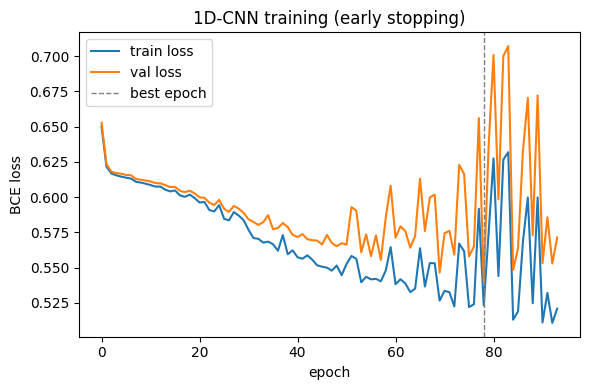

In [5]:
# train on the full training split. this model is the one used for the test set
# predictions later, so the cell is not just here for the loss curve.
model, hist = fit_cnn(Xtr_all, ytr_all, return_history=True)
hist = np.array(hist) # [epochs, 2] of (train loss, val loss)

plt.figure(figsize=(6, 4))
plt.plot(hist[:, 0], label="train loss")
plt.plot(hist[:, 1], label="val loss")
# lowest val loss. fit_cnn only saves weights on an improvement of at least 1e-4,
# so this line can sit an epoch or two off the weights actually restored.
plt.axvline(hist[:, 1].argmin(), ls="--", c="grey", lw=1, label="best epoch")
plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.legend()
plt.title("1D-CNN training (early stopping)")
plt.tight_layout()
plt.show()

## 5. Test-set performance

In [6]:
def metrics(y, p):
    """point estimates on one set of predictions. bootstrap CIs come later in phase 4.1."""
    pred = (p >= 0.5).astype(int)
    # sklearn has no specificity scorer, so unpack the confusion matrix for it
    # labels=[0, 1] fixes the order in case a set happens to hold only one class
    tn, fp, _, _ = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    # AUC takes the raw probabilities since it sweeps every threshold. everything
    # else is scored on pred, thresholded at 0.5
    return {"ACC": accuracy_score(y, pred), "AUC": roc_auc_score(y, p),
            "MCC": matthews_corrcoef(y, pred), "F1": f1_score(y, pred),
            "SN": recall_score(y, pred), "SP": tn/(tn+fp), "PREC": precision_score(y, pred)}

# predict on the test set and report the metrics
test_p = predict(model, Xte)
pd.DataFrame({"1D-CNN": metrics(yte, test_p)}).T.round(3)

,ACC,AUC,MCC,F1,SN,SP,PREC
1D-CNN,0.663,0.723,0.354,0.737,0.903,0.4,0.622


*Reference: AAC floor 0.853 | RF 0.830 | XGBoost 0.857 (test AUC).*

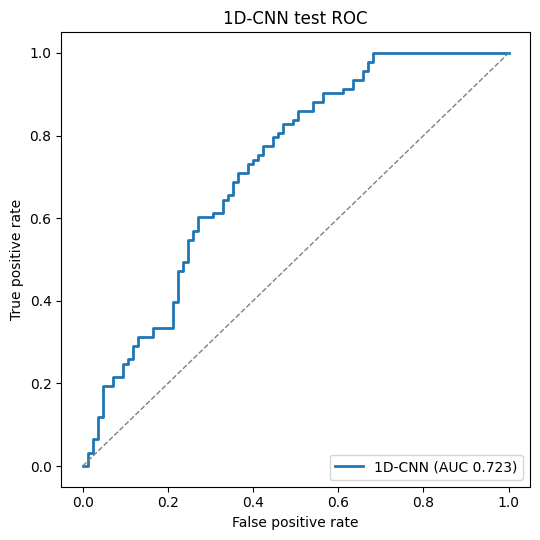

In [7]:
# diagnostic only. figure 5a in the report is the multi-model version from figures.ipynb.
fpr, tpr, _ = roc_curve(yte, test_p) # thresholds discarded, only the curve is plotted


plt.figure(figsize=(5.5, 5.5)) # square so the diagonal reads at 45 degrees
plt.plot(fpr, tpr, lw=2, label=f"1D-CNN (AUC {roc_auc_score(yte, test_p):.3f})")
plt.plot([0, 1], [0, 1], "--", c="grey", lw=1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("1D-CNN test ROC")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 6. Out-of-fold predictions for the meta-learner

In [8]:
# same fold definition as the other three learners. nothing is passed between
# scripts, they match because the seed and the row order from fusion_vectors.npz
# are identical, which is what lets phase 3.4 stack the four sets of OOF predictions.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

oof = np.zeros(len(ytr_all), dtype="float32") # one held-out prediction per training row
for k, (tri, vali) in enumerate(skf.split(Xtr_all, ytr_all)):
    m = fit_cnn(Xtr_all[tri], ytr_all[tri], seed=SEED + k) # vary init per fold
    oof[vali] = predict(m, Xtr_all[vali])

# these OOF scores run optimistic against the test set. CD-HIT in phase 1.3 only
# separated train from test, so near-duplicates survive inside the training split
# and these folds are drawn at random, putting some of them on either side.

## 7. Save model and predictions

In [9]:
# saved so phase 4.1 can run the bootstrap CIs, DeLong and McNemar tests without
# retraining anything. state_dict holds weights only, so reloading needs
# FusionCNN() built first.
torch.save(model.state_dict(), "models/base_cnn.pt")

# cnn_oof is cross-validated over the training rows, cnn_test comes from the model
# fitted on the whole training split. phase 4.1 pairs these with the other learners
# by row order alone.
np.savez_compressed("predictions/base_cnn_predictions.npz",
                    cnn_oof=oof, cnn_test=test_p,
                    y_train=ytr_all, y_test=yte)